# Distributions, redundancy, and cradinality

In [1]:
import sys, glob, warnings
warnings.filterwarnings("ignore")
sys.path.append("../../") # lets us import helper.py
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display
from helper import *
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

DATA_FILE = glob.glob("../../data/melbourne/*.csv")[0]
TARGET = "Price"
df = pd.read_csv(DATA_FILE)


df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce") # sale date: text - datetime
df["Postcode"] = df["Postcode"].astype("Int64").astype(str) # a code, not a quantity - text
LAT = next(c for c in df.columns if c.lower().startswith("lat"))# the Kaggle file spells it "Lattitude"
LON = next(c for c in df.columns if c.lower().startswith("long"))

num_cols, cat_cols = split_columns(df, TARGET)# feature lists WITHOUT the target (Date is excluded from both)
print(df.shape, "| numeric features:", len(num_cols), "| categorical features:", len(cat_cols))

(13580, 21) | numeric features: 11 | categorical features: 8


## 2a) Distributions

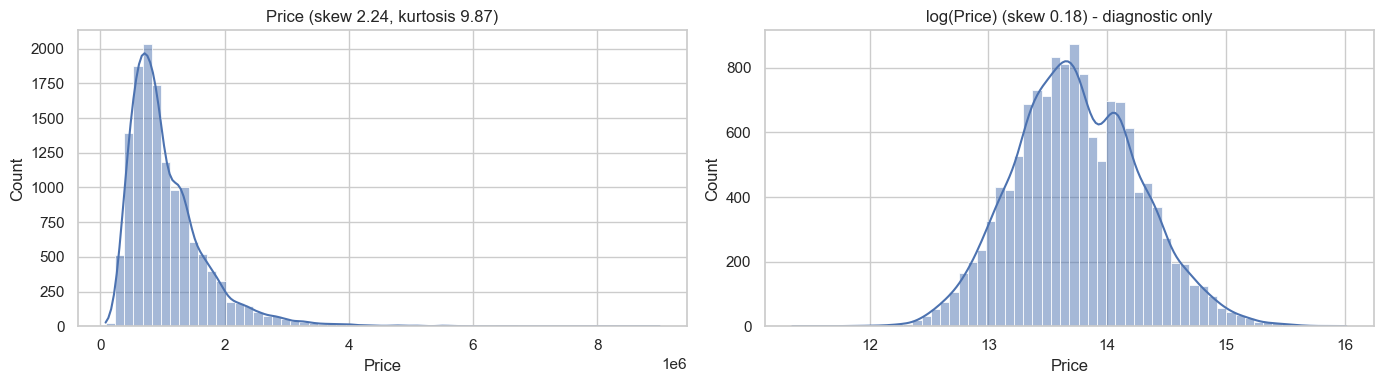

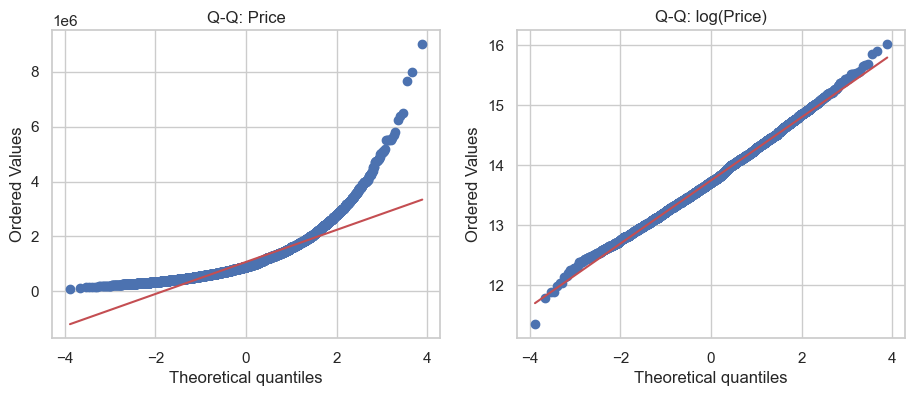

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df[TARGET].dropna(), bins=60, kde=True, ax=ax[0]); ax[0].set_title(f"Price (skew {df[TARGET].skew():.2f}, kurtosis {df[TARGET].kurt():.2f})")
sns.histplot(np.log1p(df[TARGET].dropna()), bins=60, kde=True, ax=ax[1]); ax[1].set_title(f"log(Price) (skew {np.log1p(df[TARGET]).skew():.2f}) - diagnostic only")
plt.tight_layout(); plt.show()
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
stats.probplot(df[TARGET].dropna(), dist="norm", plot=ax[0]); ax[0].set_title("Q-Q: Price")
stats.probplot(np.log1p(df[TARGET].dropna()), dist="norm", plot=ax[1]); ax[1].set_title("Q-Q: log(Price)"); plt.show()

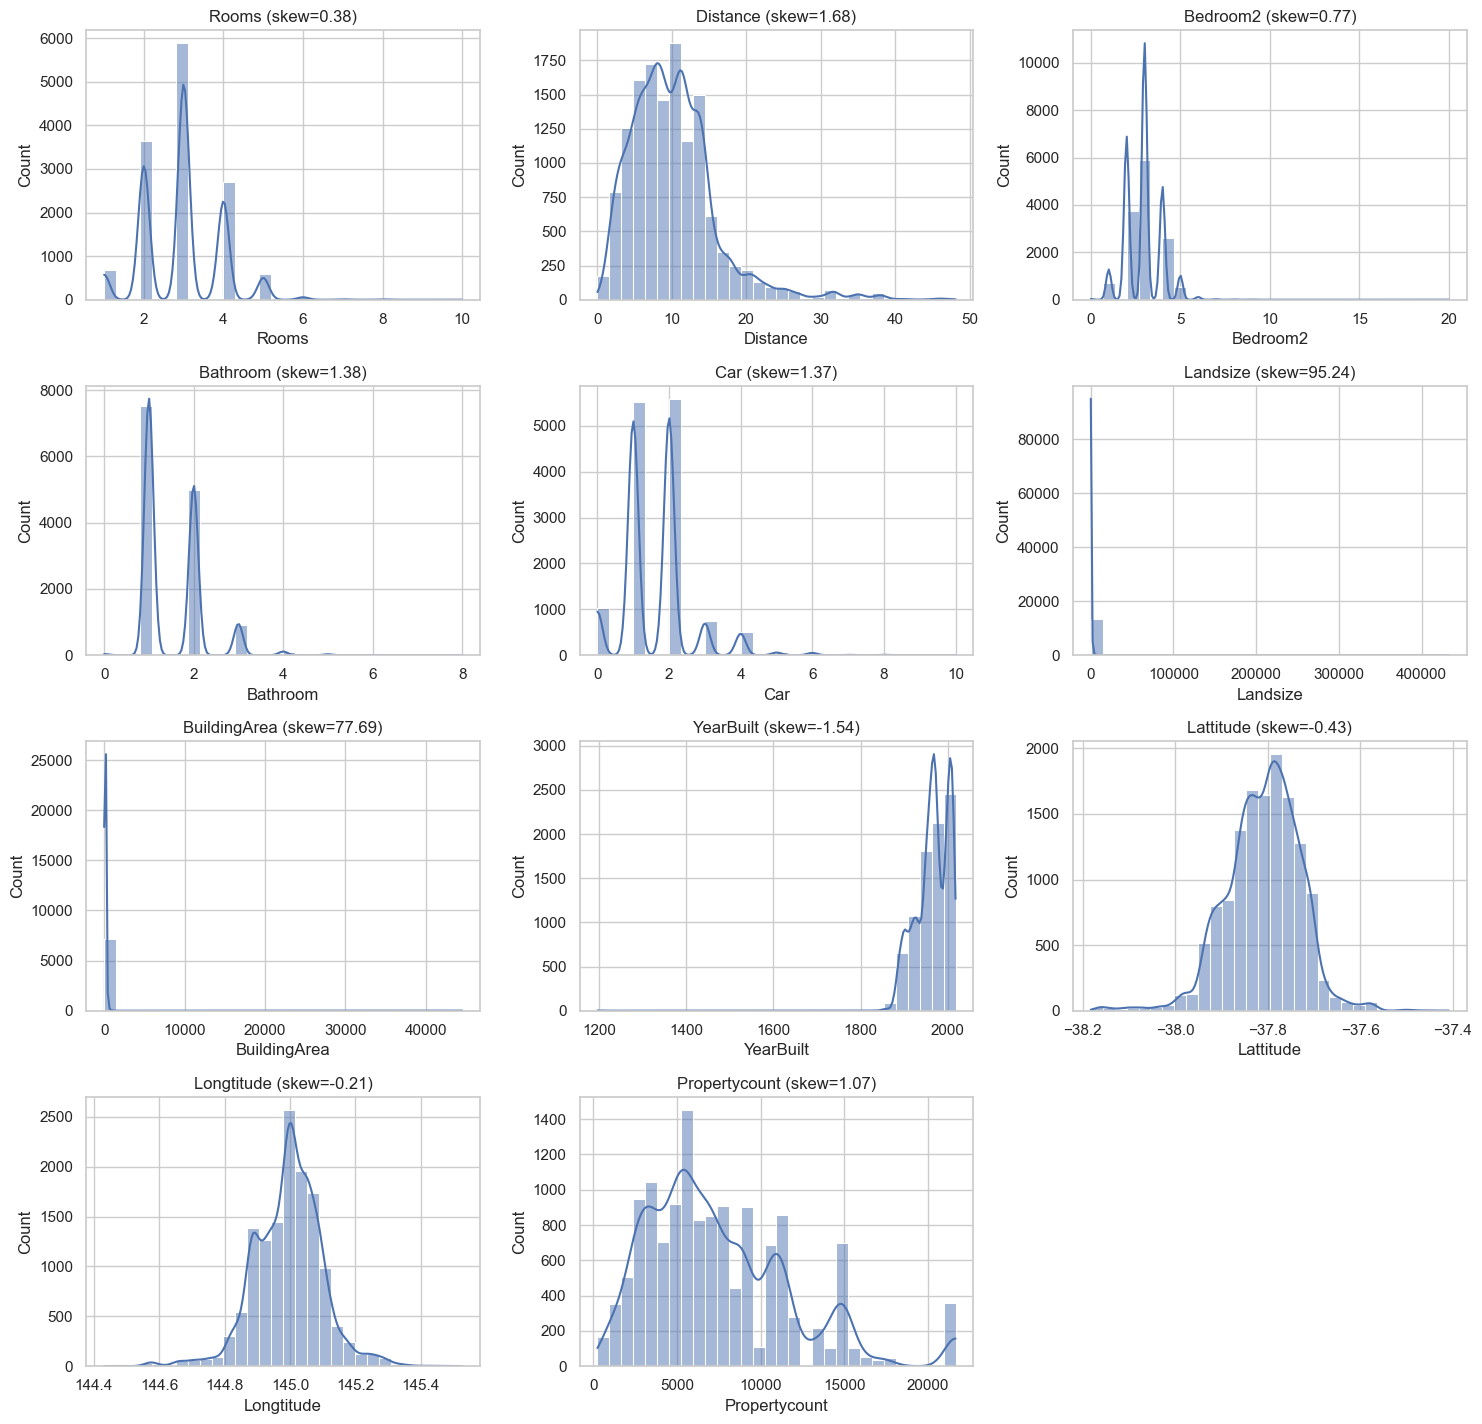

,skew,excess_kurtosis,verdict
Landsize,95.237,10180.347,highly right skewed
BuildingArea,77.692,6347.802,highly right skewed
Distance,1.677,5.260,highly right skewed
YearBuilt,-1.541,21.226,highly left skewed
Bathroom,1.377,3.595,highly right skewed
Car,1.370,5.193,highly right skewed
Propertycount,1.069,1.218,highly right skewed
Bedroom2,0.774,8.075,moderately skewed
Lattitude,-0.427,1.573,roughly symmetric
Rooms,0.376,0.794,roughly symmetric


In [3]:
hist_grid(df, num_cols)
display(skew_kurt_table(df, num_cols))

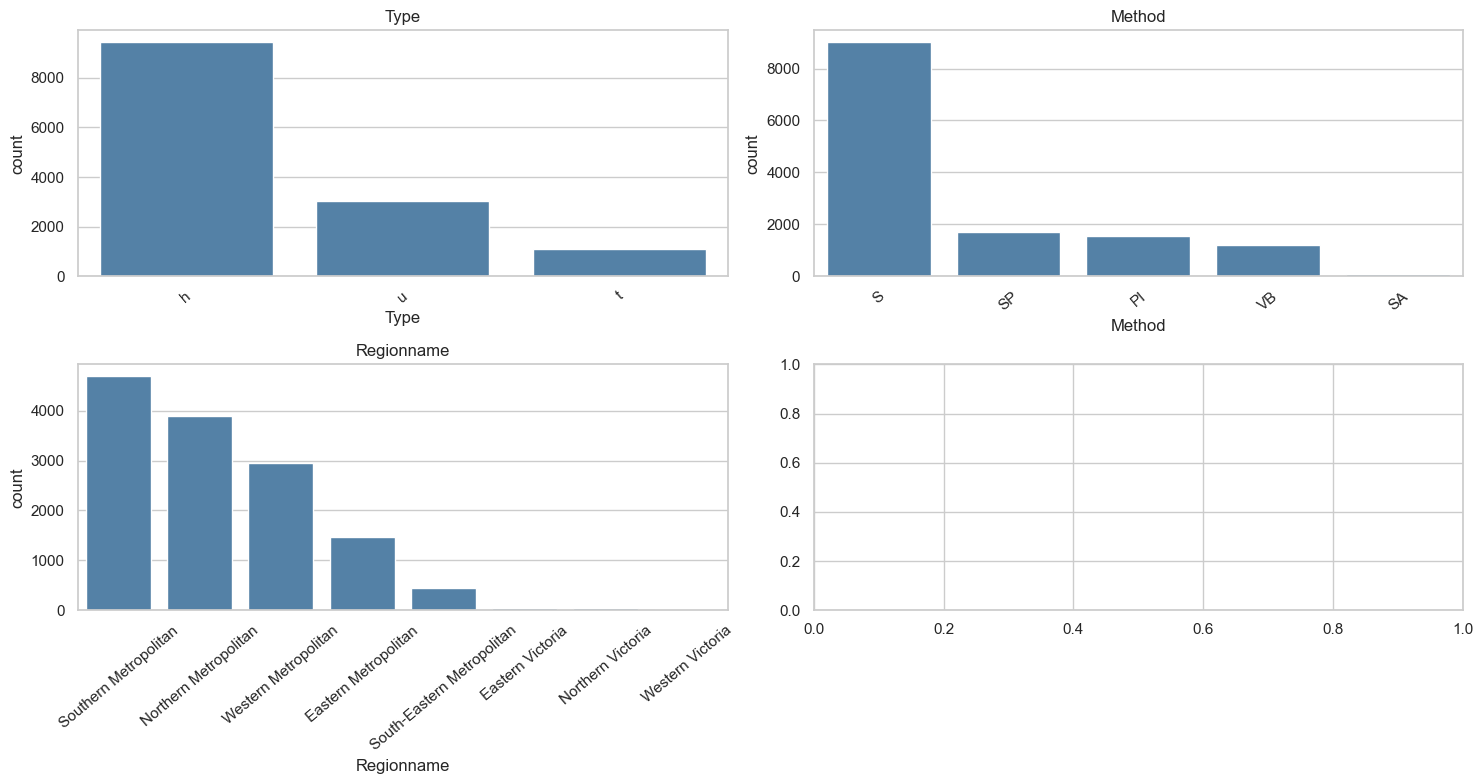

In [4]:
cats = [c for c in cat_cols if df[c].nunique() <= 15]
fig, axes = plt.subplots(int(np.ceil(len(cats)/2)), 2, figsize=(15, 4*int(np.ceil(len(cats)/2))))
for ax, col in zip(np.array(axes).ravel(), cats):
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, ax=ax, color="steelblue"); ax.set_title(col); ax.tick_params(axis="x", rotation=40)
plt.tight_layout(); plt.show()

## 2b) Multicollinearity and redundancy

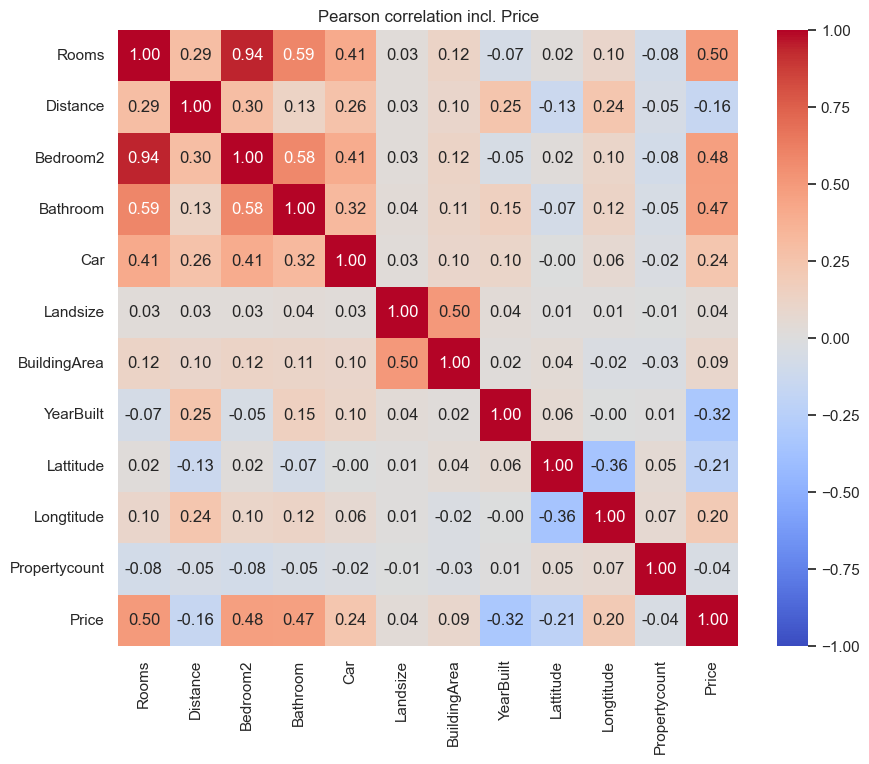

,feature_1,feature_2,abs_corr
0,Rooms,Bedroom2,0.94419


,VIF
Rooms,9.58
Bedroom2,9.36
Bathroom,1.68
Distance,1.28
Car,1.26
Longtitude,1.22
Lattitude,1.18
YearBuilt,1.11
BuildingArea,1.03
Propertycount,1.02


In [5]:
plt.figure(figsize=(10, 8)); sns.heatmap(df[num_cols + [TARGET]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Pearson correlation incl. Price"); plt.show()
display(high_corr_pairs(df, num_cols, 0.7))
display(vif_table(df, num_cols))

In [6]:
display(pd.crosstab(df["Rooms"], df["Bedroom2"]))  # does Bedroom2 just repeat Rooms?
print("Rows where Bedroom2 == Rooms:", round((df["Bedroom2"] == df["Rooms"]).mean() * 100, 1), "%")
# Propertycount should be constant inside a suburb (a suburb attribute, not a property attribute):
print("Share of suburbs with exactly 1 distinct Propertycount:", round((df.groupby("Suburb")["Propertycount"].nunique() == 1).mean() * 100, 1), "%")
print("Suburbs per Postcode / Postcodes per suburb (location redundancy):", df.groupby("Postcode")["Suburb"].nunique().mean().round(2), "/", df.groupby("Suburb")["Postcode"].nunique().mean().round(2))

Bedroom2,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,20.0
Rooms,,,,,,,,,,,,
1,0,663,16,2,0,0,0,0,0,0,0,0
2,5,21,3539,74,8,1,0,0,0,0,0,0
3,8,5,162,5626,73,5,0,0,0,1,0,1
4,3,2,19,175,2473,15,0,0,0,1,0,0
5,0,0,1,18,42,531,2,1,1,0,0,0
6,0,0,0,1,4,2,59,1,0,0,0,0
7,0,0,0,0,0,2,0,8,0,0,0,0
8,0,0,0,0,1,0,2,0,4,1,0,0
10,0,0,0,0,0,0,0,0,0,0,1,0


Rows where Bedroom2 == Rooms: 95.0 %
Share of suburbs with exactly 1 distinct Propertycount: 100.0 %
Suburbs per Postcode / Postcodes per suburb (location redundancy): 1.59 / 1.0


## 2c) High credinality

,unique,unique_%_of_rows,top_value_share_%,rare_levels(<1%)
Address,13378,98.51,0.0,13378
Suburb,314,2.31,2.6,289
SellerG,268,1.97,11.5,245
Postcode,198,1.46,2.6,161
CouncilArea,33,0.24,9.5,13
Regionname,8,0.06,34.6,3
Method,5,0.04,66.4,1
Type,3,0.02,69.6,0


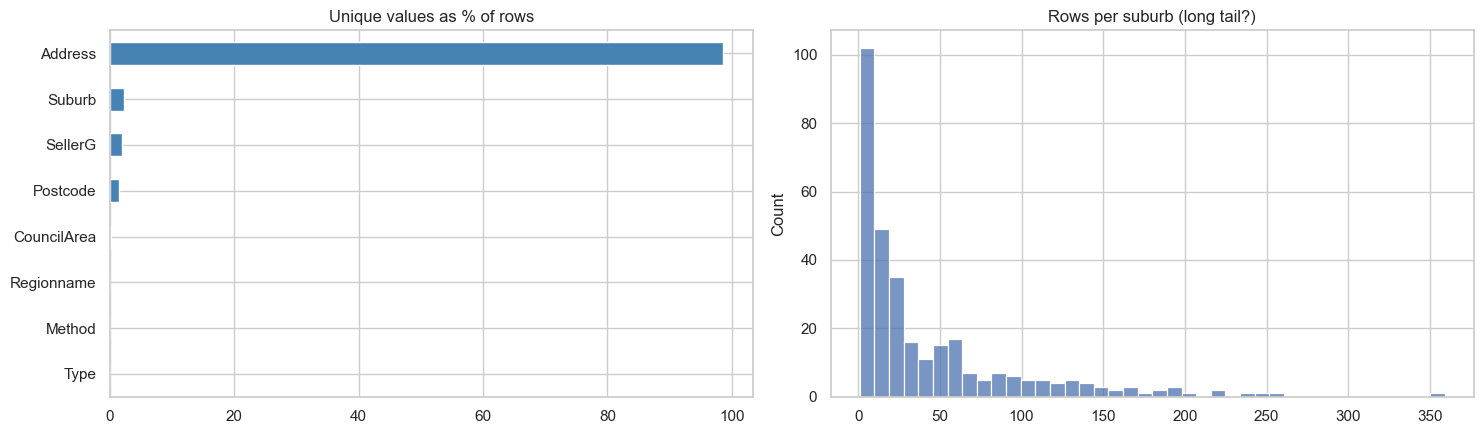

In [7]:
card = cardinality_table(df, cat_cols); display(card)
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
card["unique_%_of_rows"].sort_values().plot.barh(ax=ax[0], color="steelblue"); ax[0].set_title("Unique values as % of rows")
sns.histplot(df["Suburb"].value_counts().values, bins=40, ax=ax[1]); ax[1].set_title("Rows per suburb (long tail?)")
plt.tight_layout(); plt.show()